In [1]:
import sys
import os
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
import torch
from accelerate.test_utils.testing import get_backend
from core.callbacks import WandBCallback
from lightning.pytorch.loggers import WandbLogger
from lightning import Trainer
from core.data import FullBatchDataModule
from core.estimators import BiasWithMSE, BiasWithAutodiffLoss #, BiasWithRidgeKernelMSE
from core.utils import rbf_kernel_torch, is_psd
from core.models import KernelRegression
from functools import partial
from lightning.pytorch.callbacks import EarlyStopping
device, n_devices, _ = get_backend()
# device = "cpu"
# n_devices = 1

torch.set_float32_matmul_precision("highest")

## Kernel Regression

In [2]:
torch.manual_seed(56)
N = 500
p = 2 # input dimension / number of features
X = torch.randn(N, p)
# radial sine function sin(||x||) with some noise
# y = torch.sin(torch.norm(X, p=1, dim=1)) + 0.3 * torch.randn(N) 
y = torch.sin(torch.norm(X, p=1, dim=1))*torch.norm(X, p=2, dim=1) + 0.5 * torch.randn(N)

dm_sin = FullBatchDataModule(X, y, num_workers=3)

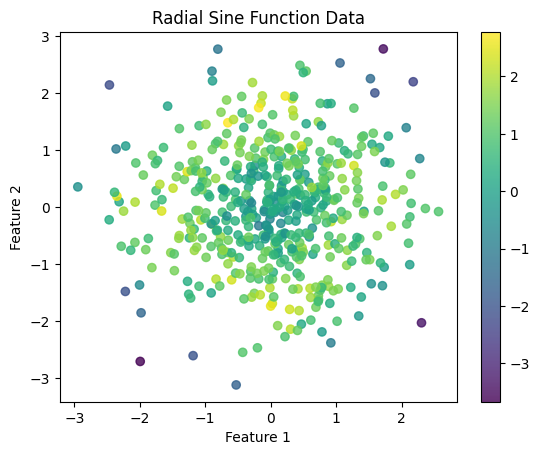

In [100]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", alpha=0.8)
plt.colorbar()
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Radial Sine Function Data")
plt.savefig("radial_sine_function_data_2d.pdf")

In [3]:
eta = 1e-2 # learning rate
lambda_ = 0.1 # regularization parameter
gamma = 100. # width of the RBF kernel
# compute RBF kernel
pre_comp_K = rbf_kernel_torch(X=X, Y=X, gamma=gamma, eps=1e-8, enforce_psd=False)
assert is_psd(pre_comp_K, tol=1e-8), "Kernel is not positive semidefinite!"
# find max eigenvalue
eigenvalues = torch.linalg.eigvalsh(pre_comp_K @ pre_comp_K / N + lambda_ * pre_comp_K)
max_eigenvalue = eigenvalues.max().item()
min_eigenvalue = eigenvalues.min().item()
print(f"Max eigenvalue of C: {max_eigenvalue:.10f}")
print(f"Min eigenvalue of C: {min_eigenvalue:.10f}")
# learning rate condition
print(f"Max learning rate: {1. / max_eigenvalue:.10f}")
assert eta < 1. / max_eigenvalue, "Learning rate is too high!"

Matrix is symmetric.
Max eigenvalue of C: 0.5186604261
Min eigenvalue of C: 0.0001170747
Max learning rate: 1.9280437635


In [4]:
# Regression with RBF kernel
rbf_kernel_reg = KernelRegression(
    kernel=partial(rbf_kernel_torch, gamma=gamma, eps=1e-8, enforce_psd=False),
    n_train_samples=N, 
    fit_intercept=False,
    ridge_lambda=lambda_,
    init_zeros=False,
    lr=eta  # no mismatch in lr for our derivation of kernel regression
)
# store the initial alphas
wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-regression", log_model=False
)

rbf_trainer = Trainer(
    max_epochs=1000,
    accumulate_grad_batches=1,
    log_every_n_steps=1,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=50, mode="min"),
    ],
    accelerator=device,
    devices=n_devices,
    # detect_anomaly=True,
)

rbf_trainer.fit(rbf_kernel_reg, dm_sin)
t = rbf_trainer.current_epoch

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | kernel_linear | Linear             | 500    | train
1 | loss_func     | KernelRidgeMSELoss | 0      | train
-------------------------------------------------------------
500       Trainable params
0         Non-trainable params
500       Total params
0.002     Total estimated model params size (MB)
2         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1000` reached.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇████
train/loss,██▇▇▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇████
epoch,999
train/loss,1.29489
trainer/global_step,999


In [5]:
K = rbf_kernel_torch(X, X, gamma=gamma, eps=1e-8, enforce_psd=False)
assert torch.isfinite(K).all()
alpha = rbf_kernel_reg.kernel_linear.weight.detach().view(-1)
# print(f"RBF Kernel Regression alphas: \n{alpha}")

In [6]:
# Estimate the quadratic form using the estimated Q from matrix ridge bias
from core.bias import DiagMatrixBiasKRR

## .detach() is essential here to detach the predictive model from the graph
alpha_init = rbf_kernel_reg.init_weights.view(-1).detach().clone()

# Use vanilla MSE loss, additional regularization is handled by the bias model
rbf_estimator = BiasWithMSE(
    predictive_model=rbf_kernel_reg,
    bias_model=DiagMatrixBiasKRR(
        Q_t_init=None,  # will be initialized as zeros
        dim=N,
        t=t,
        K=K,
        alpha_init=alpha_init,
        eta=eta,
        lambda_=lambda_,
    ),
    grad_match_loss_fn=torch.nn.functional.mse_loss,
    lr=1e-2,
    optimizer_cls=torch.optim.Adam,
)

wandb_logger = WandbLogger(
    project="inductive-bias", name="kernel-bias", log_model=False
)
rbf_trainer = Trainer(
    max_epochs=1200,
    accumulate_grad_batches=1,
    log_every_n_steps=5,
    logger=wandb_logger,
    callbacks=[
        WandBCallback(),
        EarlyStopping(monitor="train/loss", patience=50, mode="min"),
    ],
    accelerator="gpu",
    devices=n_devices,
)
rbf_trainer.fit(rbf_estimator, dm_sin)

/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /shared_data0/jrudoler/.cache/pypoetry/virtualenvs/i ...
Using default `ModelCheckpoint`. Consider installing `litmodels` package to enable `LitModelCheckpoint` for automatic upload to the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name             | Type              | Params | Mode 
---------------------------------------------------------------
0 | predictive_model | KernelRegression  | 500    | train
1 | bias_model       | DiagMatrixBiasKRR | 500    | train
---------------------------------------------------------------
1.0 K     Trainable params
0         Non-trainable params
1.0 K     Total params
0.004     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode
/shared_data0/jrudoler/.cache/pypoetry/virtualenvs/inductive-bias-v8JhmPLZ-py3.12/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=5). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=1200` reached.


bias/Q_t,▁▂▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████
bias/Q_t_grad,█▆▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇██
train/loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
bias/Q_t,2.60133
bias/Q_t_grad,0.0
epoch,1199
train/loss,0.0
trainer/global_step,1199


In [ ]:
from typing import Optional
def compute_kernel_ridge_Q_omega(K: torch.Tensor, eta: float, t: int, lambda_: float, alpha_init: torch.Tensor, device: Optional[str] = None) -> torch.Tensor:
    """
    Compute the Q matrix for kernel ridge regression.
    """
    if device is None:
        device = K.device
    K = K.to(device)
    alpha_init = alpha_init.to(device)
    dim = K.shape[0]
    I = torch.eye(dim, device=device)
    C = (1. / dim) * (K @ K) + lambda_ * K
    A = I - 2 * eta * C
    A_t = torch.linalg.matrix_power(A, t)
    Q_t = C @ (torch.linalg.inv(I - A_t) - I)

    omega_t = (C + Q_t) @ A_t @ alpha_init 

    return Q_t, omega_t
    

def compute_alpha_closed_form(K: torch.Tensor, y: torch.Tensor, Q: torch.Tensor, omega: torch.Tensor, lambda_: float) -> torch.Tensor:
    """
    Compute the closed-form solution for alpha using the kernel matrix K.
    """
    n = K.shape[0]
    C = (1 / n) * K @ K + lambda_ * K
    rhs = omega + (1 / n) * K @ y
    lhs = C + Q
    alpha = torch.linalg.solve(lhs, rhs)
    return alpha

# computations has to happen on the same device as the estimation or matrix computations
# will yield different results
Q_kernel_ridge, omega_kernel_ridge = compute_kernel_ridge_Q_omega(K, eta=eta, t=t, lambda_=lambda_, alpha_init=alpha_init, device=device)
Q_kernel_ridge = Q_kernel_ridge.detach().cpu().clone()
omega_kernel_ridge = omega_kernel_ridge.detach().cpu().clone()

In [ ]:
Q_hat_kernel_ridge = torch.diag(rbf_estimator.bias_model.Q_t.detach())
print("estimated Q from kernel ridge bias:\n", Q_hat_kernel_ridge)
# now estimate the quadratic form using the estimated Q from kernel bias
print("theoretical Q from kernel ridge regression:\n", Q_kernel_ridge)

estimated Q from kernel ridge bias:
 tensor([[-0.0152,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0708,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0144,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0117,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0152,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0143]])
theoretical Q from kernel ridge regression:
 tensor([[ 1.7110e-02, -5.8113e-17,  7.7390e-16,  ...,  2.3800e-08,
          4.0915e-25, -6.2331e-17],
        [ 6.6787e-17,  2.2643e-02, -2.5258e-15,  ..., -1.7867e-21,
         -1.8735e-29, -1.0825e-15],
        [ 5.2822e-16,  2.9837e-15,  1.9779e-02,  ..., -5.3998e-20,
          5.2093e-18, -5.8813e-22],
        ...,
        [ 2.3635e-08, -2.2202e-21,  8.8938e-21,  ...,  1.5798e-02,
         -1.0721e-27, -2.6999e-21],
        [ 4.0950e-25,  4.1711e-29,  5.1946e-18,  ..., -1.16

In [ ]:
# Compare the estimated Q from kernel bias with the one from kernel regression
theory_alpha = compute_alpha_closed_form(K = K, y= y, Q=Q_kernel_ridge, omega=omega_kernel_ridge, lambda_=lambda_)
# estimated Q and exact theoretical omega (which was used to fit Q)
estimated_alpha = compute_alpha_closed_form(K = K, y= y, Q=Q_hat_kernel_ridge, omega=omega_kernel_ridge, lambda_=lambda_)
print("theoretical alpha from Q bias:\n", theory_alpha[:25])
print("estimated alpha from Q bias:\n", estimated_alpha[:25])
print("ground truth alpha:\n", alpha[:25])

theoretical alpha from Q bias:
 tensor([ 0.0094, -0.0023,  0.0392,  0.0127,  0.0013, -0.0217,  0.0400,  0.0452,
         0.0047, -0.0049,  0.0161,  0.0010,  0.0283,  0.0215,  0.0236, -0.0085,
         0.0140,  0.0197,  0.0280,  0.0226, -0.0021,  0.0318,  0.0062,  0.0245,
        -0.0294])
estimated alpha from Q bias:
 tensor([ 0.0094, -0.0023,  0.0392,  0.0118,  0.0013, -0.0217,  0.0400,  0.0451,
         0.0047, -0.0049,  0.0161,  0.0010,  0.0283,  0.0214,  0.0236, -0.0085,
         0.0140,  0.0197,  0.0280,  0.0226, -0.0021,  0.0318,  0.0062,  0.0245,
        -0.0294])
ground truth alpha:
 tensor([ 0.0094, -0.0023,  0.0392,  0.0127,  0.0013, -0.0217,  0.0400,  0.0452,
         0.0047, -0.0049,  0.0161,  0.0010,  0.0283,  0.0215,  0.0236, -0.0085,
         0.0140,  0.0197,  0.0280,  0.0226, -0.0021,  0.0318,  0.0062,  0.0245,
        -0.0294])


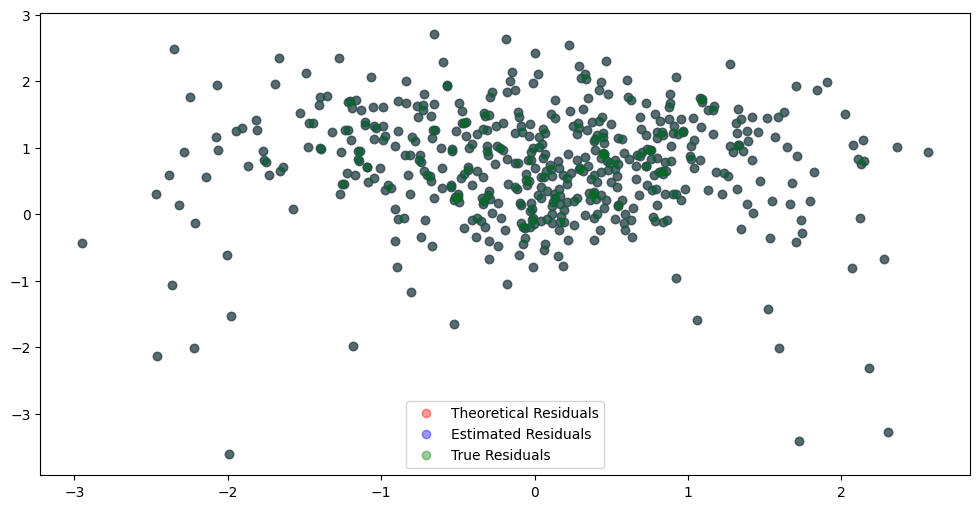

In [96]:
# predictions from the bias model
theory_resid = y - (theory_alpha @ K)
estimated_resid = y - (estimated_alpha @ K)
true_resid = y - (alpha @ K)
plt.figure(figsize=(12, 6))
plt.plot(X[:, 0], theory_resid, 'o', color="red", alpha=0.4, label='Theoretical Residuals')
plt.plot(X[:, 0], estimated_resid, 'o', color="blue", alpha=0.4, label='Estimated Residuals')
plt.plot(X[:, 0], true_resid, 'o', color="green", alpha=0.4, label='True Residuals')
plt.legend()

In [2]:
# compare RMSE
from sklearn.metrics import mean_squared_error
theory_rmse = mean_squared_error(y, theory_resid)
estimated_rmse = mean_squared_error(y, estimated_resid)
true_rmse = mean_squared_error(y, true_resid)
print(f"Theoretical RMSE: {theory_rmse:.4f}")
print(f"Estimated RMSE: {estimated_rmse:.4f}")
print(f"True RMSE: {true_rmse:.4f}")

NameError: name 'y' is not defined

In [68]:
from core.utils import is_psd

print("Is the estimated Q positive semidefinite?", is_psd(Q_hat_kernel_ridge))
print("Is the theoretical Q positive semidefinite?", is_psd(Q_kernel_ridge))

Matrix is symmetric.
Is the estimated Q positive semidefinite? True
Matrix is symmetric.
Is the theoretical Q positive semidefinite? True


In [ ]:
# import torch

# ## Device matters!!! GPU vs CPU can use different precision and yield different results

# def compare_Q_matrices(
#     K: torch.Tensor,
#     eta: float,
#     t: int,
#     lambda_: float,
#     alpha_init: torch.Tensor,
#     atol: float = 1e-8
# ) -> None:
#     n = K.size(0)
#     # 1) exact from the standalone function
#     Q_func, _ = compute_kernel_ridge_Q_omega(K, eta, t, lambda_, alpha_init)

#     # 2) exact from the class
#     model = DiagMatrixBiasKRR(
#         dim=n, t=t, K=K, alpha_init=alpha_init,
#         eta=eta, lambda_=lambda_
#     )
#     model = model  # Ensure the model is on the same device
#     # forward just to populate model.Q_t_exact
#     _ = model(alpha_init)

#     Q_cls = model.Q_t_exact.detach()
#     print(n)
#     print(model.dim)
#     print(model.t)
#     diff = (Q_func - Q_cls).abs().max().item()

#     print(f"max|Q_func – Q_cls| = {diff:.3e}")
#     if diff < atol:
#         print("✅ They match to within tolerance")
#     else:
#         print("❌ Mismatch—check your λ, t, dtype or device")

# def compare_Q_matrices_gpu(
#     K: torch.Tensor,
#     eta: float,
#     t: int,
#     lambda_: float,
#     alpha_init: torch.Tensor,
#     atol: float = 1e-8
# ) -> None:
#     n = K.size(0)
#     K = K.double().to("cuda")  # Ensure K is on the same device
#     alpha_init = alpha_init.double().to("cuda")  # Ensure alpha_init is on
#     # 1) exact from the standalone function
#     Q_func, _ = compute_kernel_ridge_Q_omega(K, eta, t, lambda_, alpha_init, device="cuda")

#     # 2) exact from the class
#     model = DiagMatrixBiasKRR(
#         dim=n, t=t, K=K, alpha_init=alpha_init,
#         eta=eta, lambda_=lambda_
#     )
#     model = model.double().to("cuda")  # Ensure the model is on the same device
#     # forward just to populate model.Q_t_exact
#     _ = model(alpha_init.double())

#     Q_cls = model.Q_t_exact.detach()
#     print(n)
#     print(model.dim)
#     print(model.t)
#     diff = (Q_func - Q_cls).abs().max().item()

#     print(f"max|Q_func – Q_cls| = {diff:.3e}")
#     if diff < atol:
#         print("✅ They match to within tolerance")
#     else:
#         print("❌ Mismatch—check your λ, t, dtype or device")

# # Example usage:
# # torch.manual_seed(0)
# # n = 5
# # K = torch.rand(n, n)
# # K = K @ K.t()  # make it SPD
# # α0 = torch.randn(N)
# compare_Q_matrices(K, eta=eta, t=t, lambda_=lambda_, alpha_init=alpha_init)